In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1
Загрузите данные из csv-файла (comma separated values, разделитель – запятая) с именем, ”№_Имя_города.csv”, где № - номер Вашего варианта, в двумерный массив (или список).

In [7]:
data = pd.read_csv('.\data\lab_2_data.csv') 
months = data.iloc(0)

data

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Gordey\AppData\Local\Temp\ipykernel_20016\3003704707.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('.\data\lab_2_data.csv')


,Год,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,средняя
0,1817,999.9,999.9,999.9,999.9,999.9,999.9,999.9,15.5,4.6,-3.1,-10.5,-25.2,999.9
1,1818,-13.0,-20.2,-4.5,0.6,5.7,13.9,14.2,14.3,9.0,-2.0,-12.2,-9.7,-0.3
2,1819,-11.0,-17.3,-6.9,-2.9,3.7,15.6,15.8,12.8,9.6,2.1,-12.5,-17.2,-0.7
3,1820,-20.2,-17.2,-2.6,2.9,8.5,15.0,17.3,12.6,8.5,2.7,-7.6,-15.1,0.4
4,1821,-12.8,-12.6,-7.3,0.1,9.3,13.2,17.1,13.5,6.3,4.0,-4.5,-11.6,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2015,-15.3,-6.6,-1.8,2.9,13.6,16.2,13.9,12.4,10.5,-0.2,-5.3,-6.6,2.8
199,2016,-16.6,-3.6,-4.7,4.8,11.4,14.6,19.9,18.1,9.0,1.8,-10.9,-15.8,2.3
200,2017,-14.2,-10.3,-1.2,1.0,5.0,12.4,18.3,16.0,7.5,2.3,-1.8,-5.5,2.5
201,2018,-9.6,-12.2,-10.8,1.6,8.1,13.5,19.5,14.5,9.6,2.9,-4.9,-9.8,1.9


# 2
Для любого заданного столбца данных (кроме первого) и любых 12-ти последовательных строчек из мас-
сива постройте интерполяционный полином Лагранжа, выведите его график на сетке с шагом h по оси X
– 0,1 вместе с исходными точками. Значение "999.9" в массиве означает отсутствие достоверных данных
и должно быть исключено из анализа.

In [8]:
month = 'янв'
first_row = 1

H = 0.1

count_rows = 12

X = []
for i in range(count_rows):
    X.append(round(H * i, 1))
data = data[data[month] != 999.9]
Y = data.iloc[first_row:first_row + count_rows]

X = list(X)
Y = list(Y[month])
X, Y, data

([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
 [-11.0,
  -20.2,
  -12.8,
  -8.9,
  -18.8,
  -18.4,
  -9.5,
  -14.9,
  -11.0,
  -26.9,
  -15.6,
  -15.1],
       Год   янв   фев   мар  апр   май   июн   июл   авг    сен    окт    ноя  \
 1    1818 -13.0 -20.2  -4.5  0.6   5.7  13.9  14.2  14.3    9.0   -2.0  -12.2   
 2    1819 -11.0 -17.3  -6.9 -2.9   3.7  15.6  15.8  12.8    9.6    2.1  -12.5   
 3    1820 -20.2 -17.2  -2.6  2.9   8.5  15.0  17.3  12.6    8.5    2.7   -7.6   
 4    1821 -12.8 -12.6  -7.3  0.1   9.3  13.2  17.1  13.5    6.3    4.0   -4.5   
 5    1822  -8.9  -4.0   0.0  2.4   4.0  13.0  16.6  13.3    9.8    1.7   -7.7   
 ..    ...   ...   ...   ...  ...   ...   ...   ...   ...    ...    ...    ...   
 198  2015 -15.3  -6.6  -1.8  2.9  13.6  16.2  13.9  12.4   10.5   -0.2   -5.3   
 199  2016 -16.6  -3.6  -4.7  4.8  11.4  14.6  19.9  18.1    9.0    1.8  -10.9   
 200  2017 -14.2 -10.3  -1.2  1.0   5.0  12.4  18.3  16.0    7.5    2.3   -1.8   
 201  2018

In [9]:
n_x = []
n_y = []
for i in range(0, len(Y)):
    if Y[i] != 999.9:
        n_x.append(X[i])
        n_y.append(Y[i])
        
X = n_x.copy()
Y = n_y.copy()

        

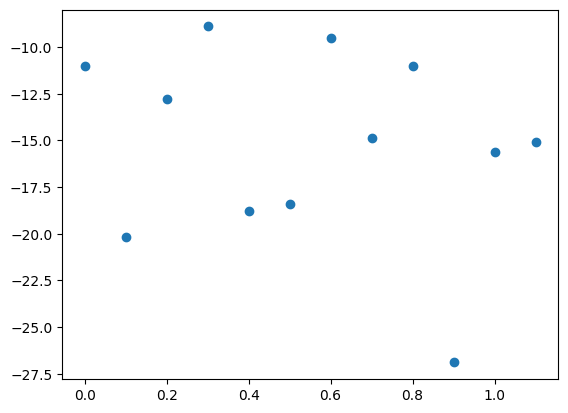

In [10]:
plt.scatter(X, Y)

In [11]:
def L_i(x, ind, table_x):
    res = 1
    for j in range(0, len(table_x)):
        if j != ind:
            res *= (x - table_x[j]) / (table_x[ind] - table_x[j])
    return res

In [12]:
def InterpolLag(x):
    global X, Y
    
    result = 0
    for i in range(0, len(X)):
        result += Y[i] * L_i(x, i, X)
    return result

Интерполяция полиномом Лагранжа
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4, -9.5, -14.9, -11.0, -26.9, -15.6, -15.1]


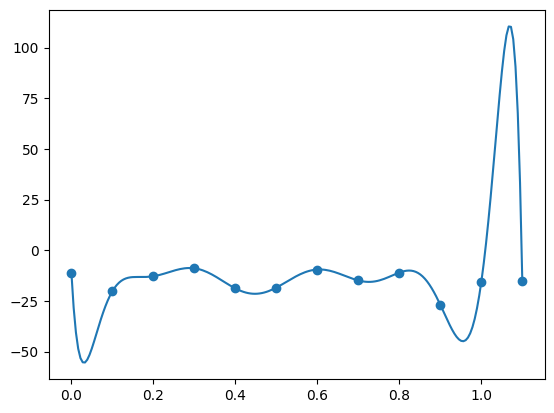

In [13]:
X_l = X
Y_l = Y


x_l = np.linspace(X_l[0], X_l[11], 200)
y_l = [InterpolLag(el) for el in x_l]


print("Интерполяция полиномом Лагранжа\nДанные:")
print(X_l, Y_l, sep='\n')
plt.plot(x_l, y_l)
plt.scatter(X_l, Y_l)

# 3
Для любого заданного столбца данных (кроме первого) и любых 6-ти последовательных строчек из массива
выполнить интерполяцию с помощью первой интерполяционной формулы Ньютона ($h = 0,1$), построить
график.

$$N_n(x) = y_0 + \frac{\Delta y_0}{h}(x - x_0) + \frac{\Delta^2 y_0}{2 h^2}(x - x_0)(x - x_1) + \cdots + \frac{\Delta^n y_0}{n! h^n}(x - x_0)(x - x_1)\cdot ... \cdot(x - x_{n - 1})$$

$$\Delta^k y_i = \sum\limits_{j = 0}^{k}(-1)^{k - j}C_k^iy_{i + j}$$

In [14]:
X_n = X[:6]
Y_n = Y[:6]

for i in range(len(X_n)):
    X_n[i] = round(X_n[i], 1)
    print(f'x, y: {X_n[i]}, {Y_n[i]}')

x, y: 0.0, -11.0
x, y: 0.1, -20.2
x, y: 0.2, -12.8
x, y: 0.3, -8.9
x, y: 0.4, -18.8
x, y: 0.5, -18.4


In [15]:
def k_coeff(ind, k):
    res = 1
    for j in range(ind):
        res *= k - j
        
    return res

In [16]:
def fact(a):
    res = 1
    for i in range(1, a + 1):
        res *= i
        
    return res

In [17]:
def x_coeff(x, ind):
    global X_n
    res = 1
    
    for i in range(ind):
        res *= x - X_n[i]
    return res

In [18]:
def C(m, n):
    return fact(n) / (fact(n - m) * fact(m))

In [19]:
def FiniteDifference(k):    
    res = 0
    for j in range(0, k + 1):
        res += np.pow(-1, k - j) * C(j, k) * Y_n[j]
    return res

In [20]:
def InterpolNewtonFK(x):
    result = Y_n[0]
    
    for i in range(1, len(X_n)):
        result += FiniteDifference(i) * x_coeff(x, i) / np.pow(H, i) / fact(i)
    return result
        

Интерполяция с помощью первой формулы Ньютона(вперёд)
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


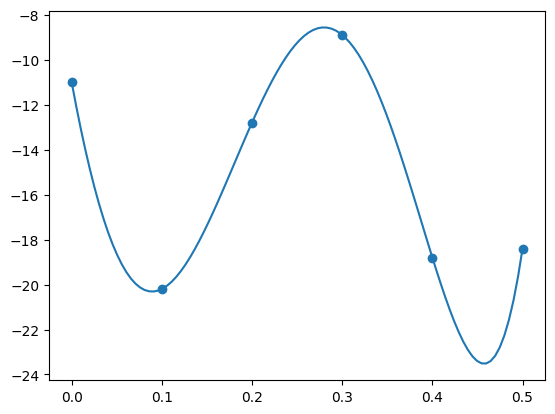

In [21]:
x_n_f = np.linspace(X_n[0], X_n[5], 100)
y_n_f = [InterpolNewtonFK(el) for el in x_n_f]


print("Интерполяция с помощью первой формулы Ньютона(вперёд)\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x_n_f, y_n_f)
plt.scatter(X_n, Y_n)

# 3
Для следующих 6-ти строчек из массива выполнить интерполяцию с помощью второй интерполяционной
формулы Ньютона (h = 0, 1), построить график.

In [22]:
n = len(Y_n) - 1

dy = np.zeros((n, n))

for i in range(n):
    dy[i][0] = Y_n[i + 1] - Y_n[i]
    
for i in range(1, n):
    for j in range(n - i):
        dy[j][i] = dy[j + 1][i - 1] - dy[j][i - 1]
dy

array([[ -9.2,  16.6, -20.1,   9.8,  24.6],
       [  7.4,  -3.5, -10.3,  34.4,   0. ],
       [  3.9, -13.8,  24.1,   0. ,   0. ],
       [ -9.9,  10.3,   0. ,   0. ,   0. ],
       [  0.4,   0. ,   0. ,   0. ,   0. ]])

In [23]:
def InterpolNewtonSK(x):
    n = len(Y_n) - 1
    result = Y_n[n]
    
    q = (x - X_n[n]) / H
    mult = 1
    
    for i in range(n):
        mult *= q + i
        
        result += dy[n - i - 1][i] * mult / fact(i + 1)
    return result

Интерполяция с помощью второй формулы Ньютона(назад)
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


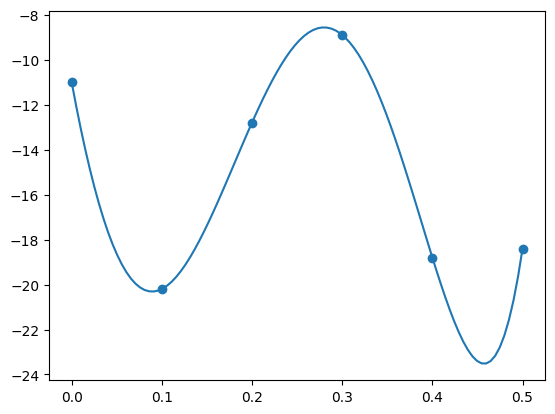

In [24]:
x_n_s = np.linspace(X_n[0], X_n[5], 100)
y_n_s = [InterpolNewtonSK(el) for el in x_n_s]


print("Интерполяция с помощью второй формулы Ньютона(назад)\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x_n_s, y_n_s)
plt.scatter(X_n, Y_n)

# 5
Для любого заданного столбца данных (кроме первого) и всех строчек массива, не содержащих недосто-
верные значения, выполнить аппроксимацию степенным полиномом (степень полинома – до 5), построить
график.

$$\overline{F(x)} = C_0 + C_1 x + C_2 x^2 + C_3 x^3 + C_4 x^4 + C_5 x^5$$

Необходимо решить матричное уравнение вида $AX = B$, где $X$ - матрица коэффициентов $C_i$

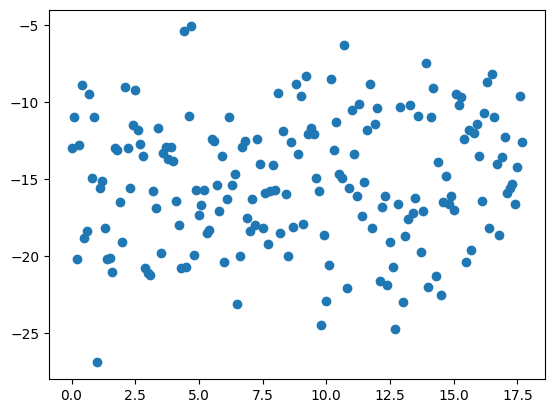

In [25]:
H = 0.1

Y_p = list(data[month])
X_p = [round(H * i, 1) for i in range(len(Y_p))]

plt.scatter(X_p, Y_p)

In [26]:
def MakeMatrix(n, m, value=0):
    res = []
    for i in range(n):
        res.append([])
        for j in range(m):
            res[i].append(value)
    return res

def MatrixMultiplication(A, B):
    result = MakeMatrix(len(A), len(B[0])) 
    #print(result)
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(A[0])):
                result[i][j] += A[i][k] * B[k][j]
    return result

In [27]:
def XMatrix(N_):
    X = np.zeros((N_ + 1, N_ + 1))
    
    for i in range(N_ + 1):
        for j in range(N_ + 1):
            elem = 0
            for k in range(len(X_p)):
                elem += X_p[k]**(i + j)
            X[i][j] = elem
    return X

In [28]:
def XYMatrix(N_):
    XY = np.zeros((N_ + 1, 1))
    
    for i in range(N_ + 1):
        for k in range(len(X_p)):
            XY[i][0] += Y_p[k] * X_p[k]**i
    return XY

In [29]:
n_ = len(Y_p)
N = 5

In [30]:
X_matr = XMatrix(N)

Y_matr = XYMatrix(N)

X_matr, Y_matr, len(X_matr)

(array([[1.78000000e+02, 1.57530000e+03, 1.86410500e+04, 2.48157009e+05,
         3.52379225e+06, 5.21220710e+07],
        [1.57530000e+03, 1.86410500e+04, 2.48157009e+05, 3.52379225e+06,
         5.21220710e+07, 7.92987495e+08],
        [1.86410500e+04, 2.48157009e+05, 3.52379225e+06, 5.21220710e+07,
         7.92987495e+08, 1.23158590e+10],
        [2.48157009e+05, 3.52379225e+06, 5.21220710e+07, 7.92987495e+08,
         1.23158590e+10, 1.94312775e+11],
        [3.52379225e+06, 5.21220710e+07, 7.92987495e+08, 1.23158590e+10,
         1.94312775e+11, 3.10407268e+12],
        [5.21220710e+07, 7.92987495e+08, 1.23158590e+10, 1.94312775e+11,
         3.10407268e+12, 5.00871208e+13]]),
 array([[-2.69580000e+03],
        [-2.35619100e+04],
        [-2.75810067e+05],
        [-3.63686868e+06],
        [-5.11960629e+07],
        [-7.51278223e+08]]),
 6)

In [31]:
polinom_coeff = np.linalg.solve(X_matr , Y_matr)
polinom_coeff

array([[-1.44174456e+01],
       [-1.38597089e+00],
       [ 4.70082815e-01],
       [-6.06544835e-02],
       [ 3.26567290e-03],
       [-6.07176490e-05]])

In [32]:
x_p = np.linspace(X_p[0], X_p[n_ - 1], 100)
y_p = [0] * len(x_p)

for i in range(len(x_p)):
    for n in range(N + 1):
        y_p[i] += polinom_coeff[n][0] * x_p[i]**n

    

Аппроксимация полиномом степени N=5
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9.0, 9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9, 10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11.0, 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12.0, 12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13.0, 13.1, 13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14.0, 14.1, 14.2, 14.3, 14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15.0, 15.1, 15.2, 15.3, 15.4, 15.5, 15.6, 15.7, 15.8, 15.9, 16.0, 16.1, 16.2, 16.3, 16.4, 16.5, 16.6, 16.7, 16.8, 16.9, 17.0, 17.1, 17.2, 17.3, 17.4, 17.5,

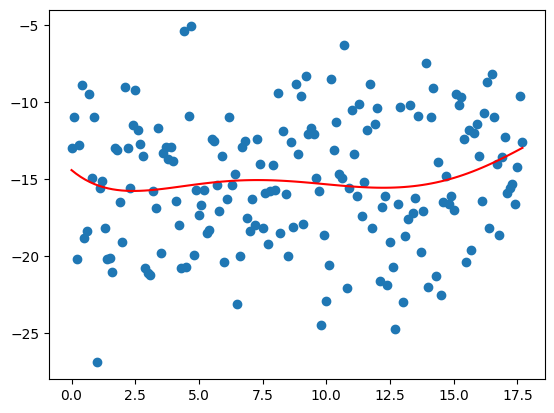

In [33]:
print(f"Аппроксимация полиномом степени N={N}\nДанные:")
print(X_p, Y_p, sep='\n')

plt.plot(x_p, y_p, color='red')
plt.scatter(X_p, Y_p)

# Дополнительные задания
## 1
Для любого заданного столбца данных (кроме первого) и любых 12-ти последовательных строчек из массива выполнить интерполяцию на сетке с $h = 0,1$ с помощью кубического сплайна, построить график (+2
балла).

$$S(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3 $$

$$h_i = 0,1 - const$$

$a_i = y_i$

$c_0 = 0, c_{11} = 0$

$$\frac{0.1}{3} c_{i - 1} + \frac{2 \cdot 0.2}{3} c_i + \frac{0.1}{3}c_{i + 1} = \frac{y_{i + 1} - y_i}{0.1} - \frac{y_i - y_{i-1}}{0.1}, i = 1,...,11$$

$$ b_{i - 1} = \frac{y_i - y_{i - 1}}{h} - \frac{h}{3}{c_i + 2c_{i - 1}} $$

In [34]:
X_s = X.copy()
Y_s = Y.copy()

n = len(Y_s)
X_s, Y_s

([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
 [-11.0,
  -20.2,
  -12.8,
  -8.9,
  -18.8,
  -18.4,
  -9.5,
  -14.9,
  -11.0,
  -26.9,
  -15.6,
  -15.1])

In [35]:
a = [Y_s[j] for j in range(0, n)]
a

[-11.0,
 -20.2,
 -12.8,
 -8.9,
 -18.8,
 -18.4,
 -9.5,
 -14.9,
 -11.0,
 -26.9,
 -15.6,
 -15.1]

In [36]:
def r_coef(k):
    return 10 * (Y_s[k + 1] + Y_s[k - 1] - 2 * Y_s[k])   

In [37]:
matrix_C = np.zeros((n - 2, n))

for i in range(n - 2):
        matrix_C[i][i] = 0.1 / 3
        matrix_C[i][i + 1]     = 0.4 / 3
        matrix_C[i][i + 2] = 0.1 / 3 
matrix_C = [matrix_C[i][1:11] for i in range(len(matrix_C))]
matrix_C

[array([0.13333333, 0.03333333, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([0.03333333, 0.13333333, 0.03333333, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([0.        , 0.03333333, 0.13333333, 0.03333333, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([0.        , 0.        , 0.03333333, 0.13333333, 0.03333333,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([0.        , 0.        , 0.        , 0.03333333, 0.13333333,
        0.03333333, 0.        , 0.        , 0.        , 0.        ]),
 array([0.        , 0.        , 0.        , 0.        , 0.03333333,
        0.13333333, 0.03333333, 0.        , 0.        , 0.        ]),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.03333333, 0.13333333, 0.03333333, 0.        , 0.        ]),
 array([0.        , 0.        , 0.

In [38]:
matrix_r = [[r_coef(k)] for k in range(1, n - 1)]
matrix_r

[[165.99999999999997],
 [-35.0],
 [-138.0],
 [103.00000000000004],
 [84.99999999999997],
 [-142.99999999999997],
 [93.0],
 [-197.99999999999997],
 [271.99999999999994],
 [-108.0]]

In [39]:
c = np.linalg.solve(matrix_C, matrix_r)
c = [[0]] + c.tolist() + [[0]]
c = [c[i][0] for i in range(len(c))]

c

[0,
 1319.8082763285809,
 -299.23310531432446,
 -1172.8758550712832,
 850.736525599458,
 859.9297526734531,
 -1740.4555362932713,
 1811.8923924996323,
 -2717.114033705258,
 3116.5637423214016,
 -1589.1409355803507,
 0]

In [40]:
d = [(c[m] - c[m - 1]) / 0.3 for m in range(1, n)]
d

[4399.36092109527,
 -5396.804605476352,
 -2912.1424991898625,
 6745.374602235805,
 30.644090246650347,
 -8667.950963222414,
 11841.159762643012,
 -15096.688087349634,
 19445.592586755534,
 -15685.68225967251,
 5297.1364519345025]

In [41]:
b = [(Y_s[i + 1] - Y[i]) / H - H/3 * (c[i + 1] + 2 * c[i]) for i in range(0, n - 1)]
b

[-135.99360921095268,
 -4.0127815780945895,
 98.04473552333107,
 -49.16616051522972,
 -81.38009346241228,
 89.68653436487882,
 1.6339560028970084,
 8.777641623533114,
 -81.7445224970295,
 -41.799551635415085,
 110.94272903869005]

In [42]:
def sum_s(x, i):
    return a[i] + b[i] * (x - X_s[i]) + c[i] * (x - X_s[i])**2 + d[i] * (x - X_s[i])**3

In [43]:
dx = np.linspace(0, H, 20)
y_s = [0] * 20 * (n - 1)

print(len(y_s))

for i in range(0, n - 1):
    for j in range(0, len(dx)):
        y_s[i * 20 + j] += sum_s(i * H + dx[j], i) 
        

x_s = np.linspace(0, X_s[n - 1], 220)        

len(x_s), len(y_s)

220


(220, 220)

Интерполяция с помощью кубического сплайна n=12
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4, -9.5, -14.9, -11.0, -26.9, -15.6, -15.1]


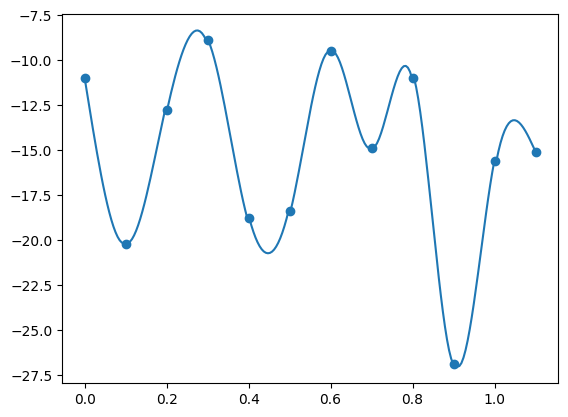

In [44]:
print(f"Интерполяция с помощью кубического сплайна n={12}\nДанные:")
print(X_s, Y_s, sep='\n')

plt.plot(x_s ,y_s)
plt.scatter(X_s, Y_s)

# 2
Для любого заданного столбца данных (кроме первого) и всех строчек массива, не содержащих недосто-
верные значения, выполнить интерполяцию на сетке с $h = 0.1$ с помощью тригонометрических функций
($\sin(kx)$ и/или $\cos(kx)$) (+1 балл), построить график.

# 3
ля любого заданного столбца данных (кроме первого) и всех строчек массива, не содержащих недостовер-
ные значения, выполнить аппроксимацию на сетке с h = 0, 1 с помощью системы ортогональных функций
$\{\phi_k = \exp(jkx)\}$ (+2 балла)